# Analyse Local vs Global Amplitude Damping

This notebook loads both saved CSV files and starts with a simple comparison plot between the local and global cases.

We benchmark all the codes listed in manuscript and perform an all-to-all comparsion. 

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "README.md").exists():
        repo_root = candidate
        break
if repo_root is None:
    repo_root = cwd

data_dir = repo_root / "datas"
local_csv = data_dir / "local_amp_damp_results.csv"
global_csv = data_dir / "global_amp_damp_results.csv"

if not local_csv.exists():
    raise FileNotFoundError(f"Missing local CSV: {local_csv}")
if not global_csv.exists():
    raise FileNotFoundError(f"Missing global CSV: {global_csv}")

df_local = pd.read_csv(local_csv)
df_global = pd.read_csv(global_csv)

print(f"Loaded local:  {local_csv}")
print(f"Loaded global: {global_csv}")
print("\nLocal shape:", df_local.shape)
print("Global shape:", df_global.shape)
display(df_local.head())
display(df_global.head())

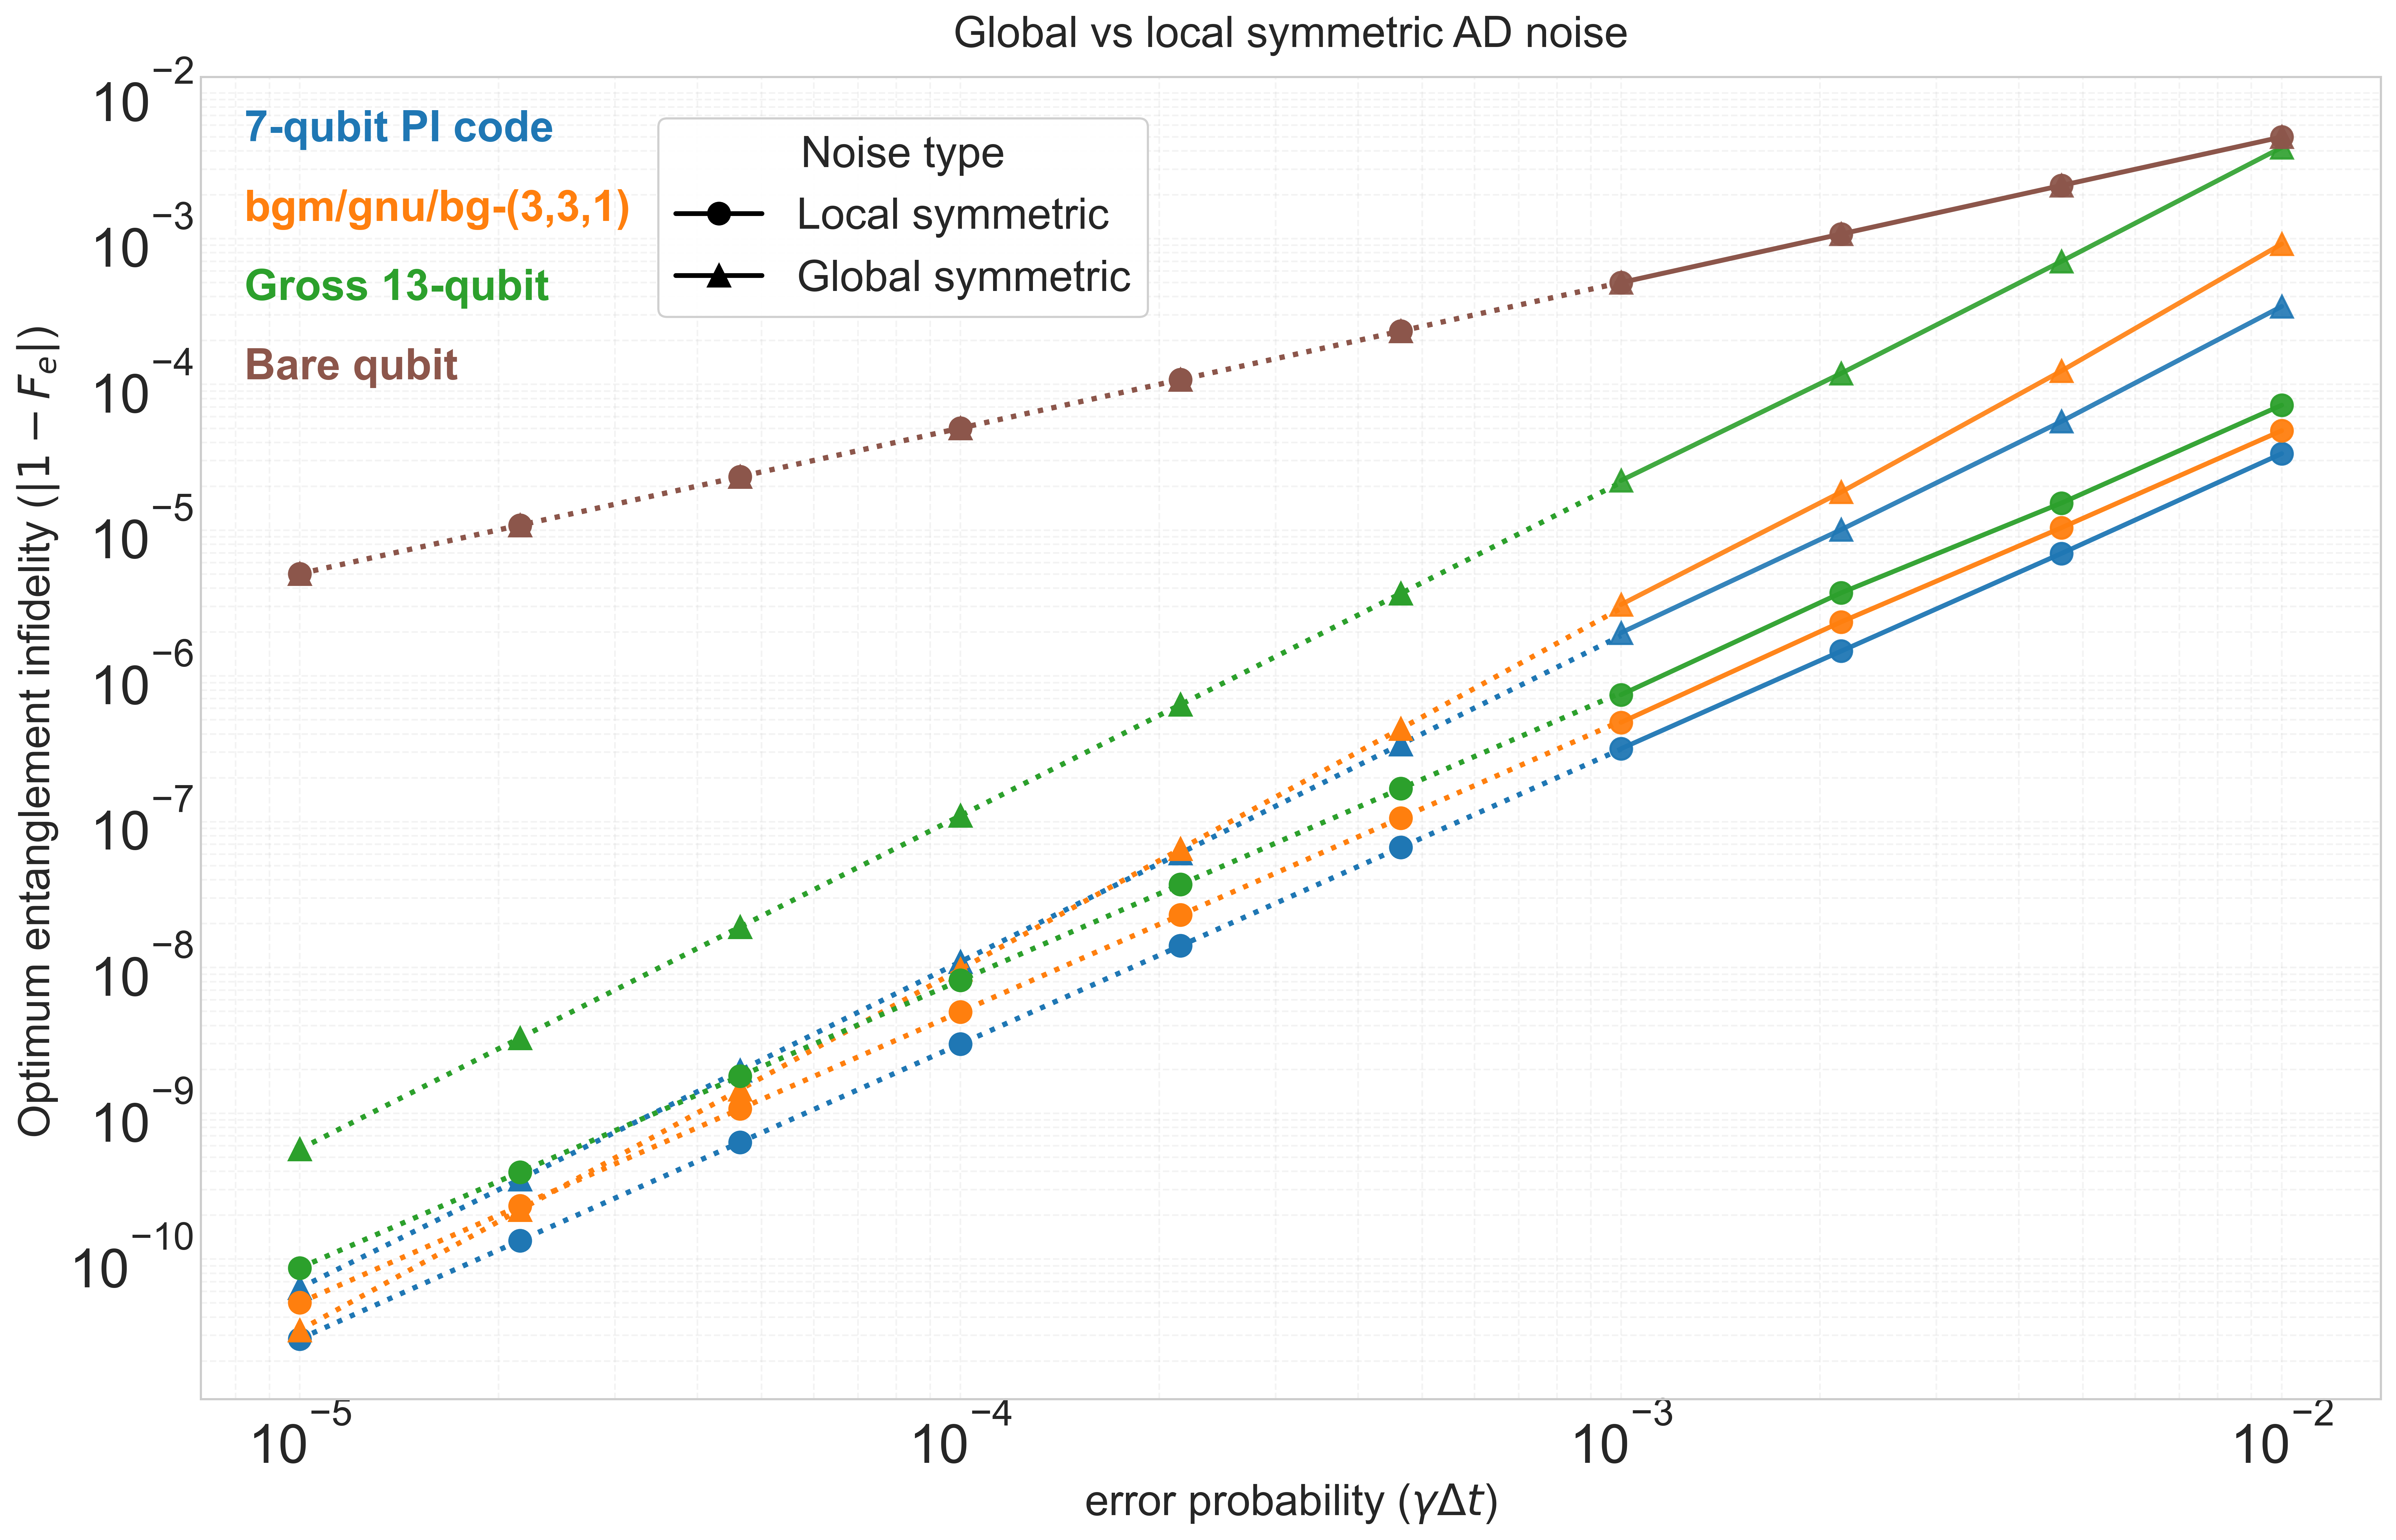

In [42]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use("seaborn-v0_8-whitegrid")

# Allow this cell to run standalone, even if Cell 2 has not been run yet.
if "df_local" not in globals() or "df_global" not in globals():
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "README.md").exists():
            repo_root = candidate
            break
    if repo_root is None:
        repo_root = cwd

    data_dir = repo_root / "datas"
    local_csv = data_dir / "local_amp_damp_results.csv"
    global_csv = data_dir / "global_amp_damp_results.csv"

    if not local_csv.exists():
        raise FileNotFoundError(f"Missing local CSV: {local_csv}")
    if not global_csv.exists():
        raise FileNotFoundError(f"Missing global CSV: {global_csv}")

    df_local = pd.read_csv(local_csv)
    df_global = pd.read_csv(global_csv)

required_col = "gamma_dt"
code_specs = [
    ("seven", "7-qubit PI code"),
    ("bgm", "bgm/gnu/bg-(3,3,1)"),
    ("gross13", "Gross 13-qubit"),
    ("bare", "Bare qubit"),
]

fit_threshold = 1e-3
min_fit_points = 3

def prepare_case(df, case_name):
    if required_col not in df.columns:
        raise ValueError(f"{case_name} CSV is missing required column '{required_col}'")

    out = df.copy()
    for prefix, _ in code_specs:
        opt_col = f"{prefix}_optimal"
        if opt_col not in out.columns:
            raise ValueError(f"{case_name} CSV is missing expected optimal column for '{prefix}'")
        out[f"{prefix}_best"] = out[opt_col]

    return out

def split_and_fit_from_high_p(p, y, threshold, min_points=3):
    valid = np.isfinite(p) & np.isfinite(y) & (p > 0) & (y > 0)
    p = p[valid]
    y = y[valid]

    order = np.argsort(p)
    p = p[order]
    y = y[order]

    low_mask = p < threshold
    high_mask = p >= threshold

    coeff = None
    if np.count_nonzero(high_mask) >= min_points and np.any(low_mask):
        coeff = np.polyfit(np.log10(p[high_mask]), np.log10(y[high_mask]), 1)

    return p, y, low_mask, high_mask, coeff

df_local = prepare_case(df_local, "local")
df_global = prepare_case(df_global, "global")

fig, ax = plt.subplots(figsize=(15.5, 10.0), dpi=500)

palette = {
    "seven": "#1f77b4",
    "bgm": "#ff7f0e",
    "gross13": "#2ca02c",
    "bare": "#8c564b",
}
label_fontsize = 20.0
noise_styles = {
    "local": {"marker": "o", "linestyle": "-", "alpha": 0.95},
    "global": {"marker": "^", "linestyle": "-", "alpha": 0.90},
}
fit_linestyle = ":"

for prefix, title in code_specs:
    local_vals = df_local[["gamma_dt", f"{prefix}_best"]].dropna()
    global_vals = df_global[["gamma_dt", f"{prefix}_best"]].dropna()

    p_local = local_vals["gamma_dt"].to_numpy(dtype=float)
    y_local = local_vals[f"{prefix}_best"].to_numpy(dtype=float)
    p_global = global_vals["gamma_dt"].to_numpy(dtype=float)
    y_global = global_vals[f"{prefix}_best"].to_numpy(dtype=float)

    p_local, y_local, low_local, high_local, coeff_local = split_and_fit_from_high_p(
        p_local, y_local, fit_threshold, min_fit_points
    )
    p_global, y_global, low_global, high_global, coeff_global = split_and_fit_from_high_p(
        p_global, y_global, fit_threshold, min_fit_points
    )

    # Computed points above threshold: solid lines with requested markers.
    if np.any(high_local):
        ax.loglog(
            p_local[high_local],
            y_local[high_local],
            color=palette[prefix],
            marker=noise_styles["local"]["marker"],
            linestyle=noise_styles["local"]["linestyle"],
            ms=10,
            lw=2.2,
            alpha=noise_styles["local"]["alpha"],
            label=f"{title} - local",
        )
    if np.any(high_global):
        ax.loglog(
            p_global[high_global],
            y_global[high_global],
            color=palette[prefix],
            marker=noise_styles["global"]["marker"],
            linestyle=noise_styles["global"]["linestyle"],
            ms=10,
            lw=2.2,
            alpha=noise_styles["global"]["alpha"],
            label=f"{title} - global",
        )

    # Fitted extrapolation below threshold: dotted, same marker style.
    if np.any(low_local) and coeff_local is not None:
        p_fit_local = np.logspace(np.log10(p_local[low_local].min()), np.log10(fit_threshold), 60)
        y_fit_local = 10 ** np.polyval(coeff_local, np.log10(p_fit_local))
        ax.loglog(
            p_fit_local,
            y_fit_local,
            color=palette[prefix],
            linestyle=fit_linestyle,
            lw=2.4,
            alpha=1.0,
        )
        y_fit_local_pts = 10 ** np.polyval(coeff_local, np.log10(p_local[low_local]))
        ax.loglog(
            p_local[low_local],
            y_fit_local_pts,
            color=palette[prefix],
            marker=noise_styles["local"]["marker"],
            linestyle="None",
            ms=10,
            alpha=1.0,
        )

    if np.any(low_global) and coeff_global is not None:
        p_fit_global = np.logspace(np.log10(p_global[low_global].min()), np.log10(fit_threshold), 60)
        y_fit_global = 10 ** np.polyval(coeff_global, np.log10(p_fit_global))
        ax.loglog(
            p_fit_global,
            y_fit_global,
            color=palette[prefix],
            linestyle=fit_linestyle,
            lw=2.4,
            alpha=1.0,
        )
        y_fit_global_pts = 10 ** np.polyval(coeff_global, np.log10(p_global[low_global]))
        ax.loglog(
            p_global[low_global],
            y_fit_global_pts,
            color=palette[prefix],
            marker=noise_styles["global"]["marker"],
            linestyle="None",
            ms=10,
            alpha=1.0,
        )

ax.set_title("Global vs local symmetric AD noise", fontsize=20, pad=14)
ax.grid(True, which="both", ls="--", alpha=0.22)
ax.set_axisbelow(True)

code_label_positions = [0.96, 0.90, 0.84, 0.78]
for (prefix, title), y_pos in zip(code_specs, code_label_positions):
    ax.text(
        0.02,
        y_pos,
        title,
        transform=ax.transAxes,
        color=palette[prefix],
        fontsize=label_fontsize,
        fontweight="semibold",
        ha="left",
        va="center",
    )

noise_handles = [
    Line2D([0], [0], color="black", marker="o", linestyle="-", lw=2.2, ms=10, label="Local symmetric"),
    Line2D([0], [0], color="black", marker="^", linestyle="-", lw=2.2, ms=10, label="Global symmetric"),
]
ax.legend(
    handles=noise_handles,
    loc="upper left",
    bbox_to_anchor=(0.20, 0.985),
    frameon=True,
    framealpha=0.92,
    title="Noise type",
    fontsize=label_fontsize,
    title_fontsize=label_fontsize,
 )

ax.set_xlabel(r"error probability ($ \gamma \Delta t$)", fontsize=20)
ax.set_ylabel(r" Optimum entanglement infidelity ($|1 - F_e|$)", fontsize=20)

ax.tick_params(axis="both", which="major", labelsize=25)
fig.tight_layout()
plt.show()

# Pick a code and analyse the various cases
1. Now I will pick code say 3,3,1 bgm code and plot the local symmetric AD and global symmetric AD with and without the optimum recovery along with a bare qubit case. The aim of this plot is to send a message that encoding in PI codes is doing a great deal in error suppresion.  

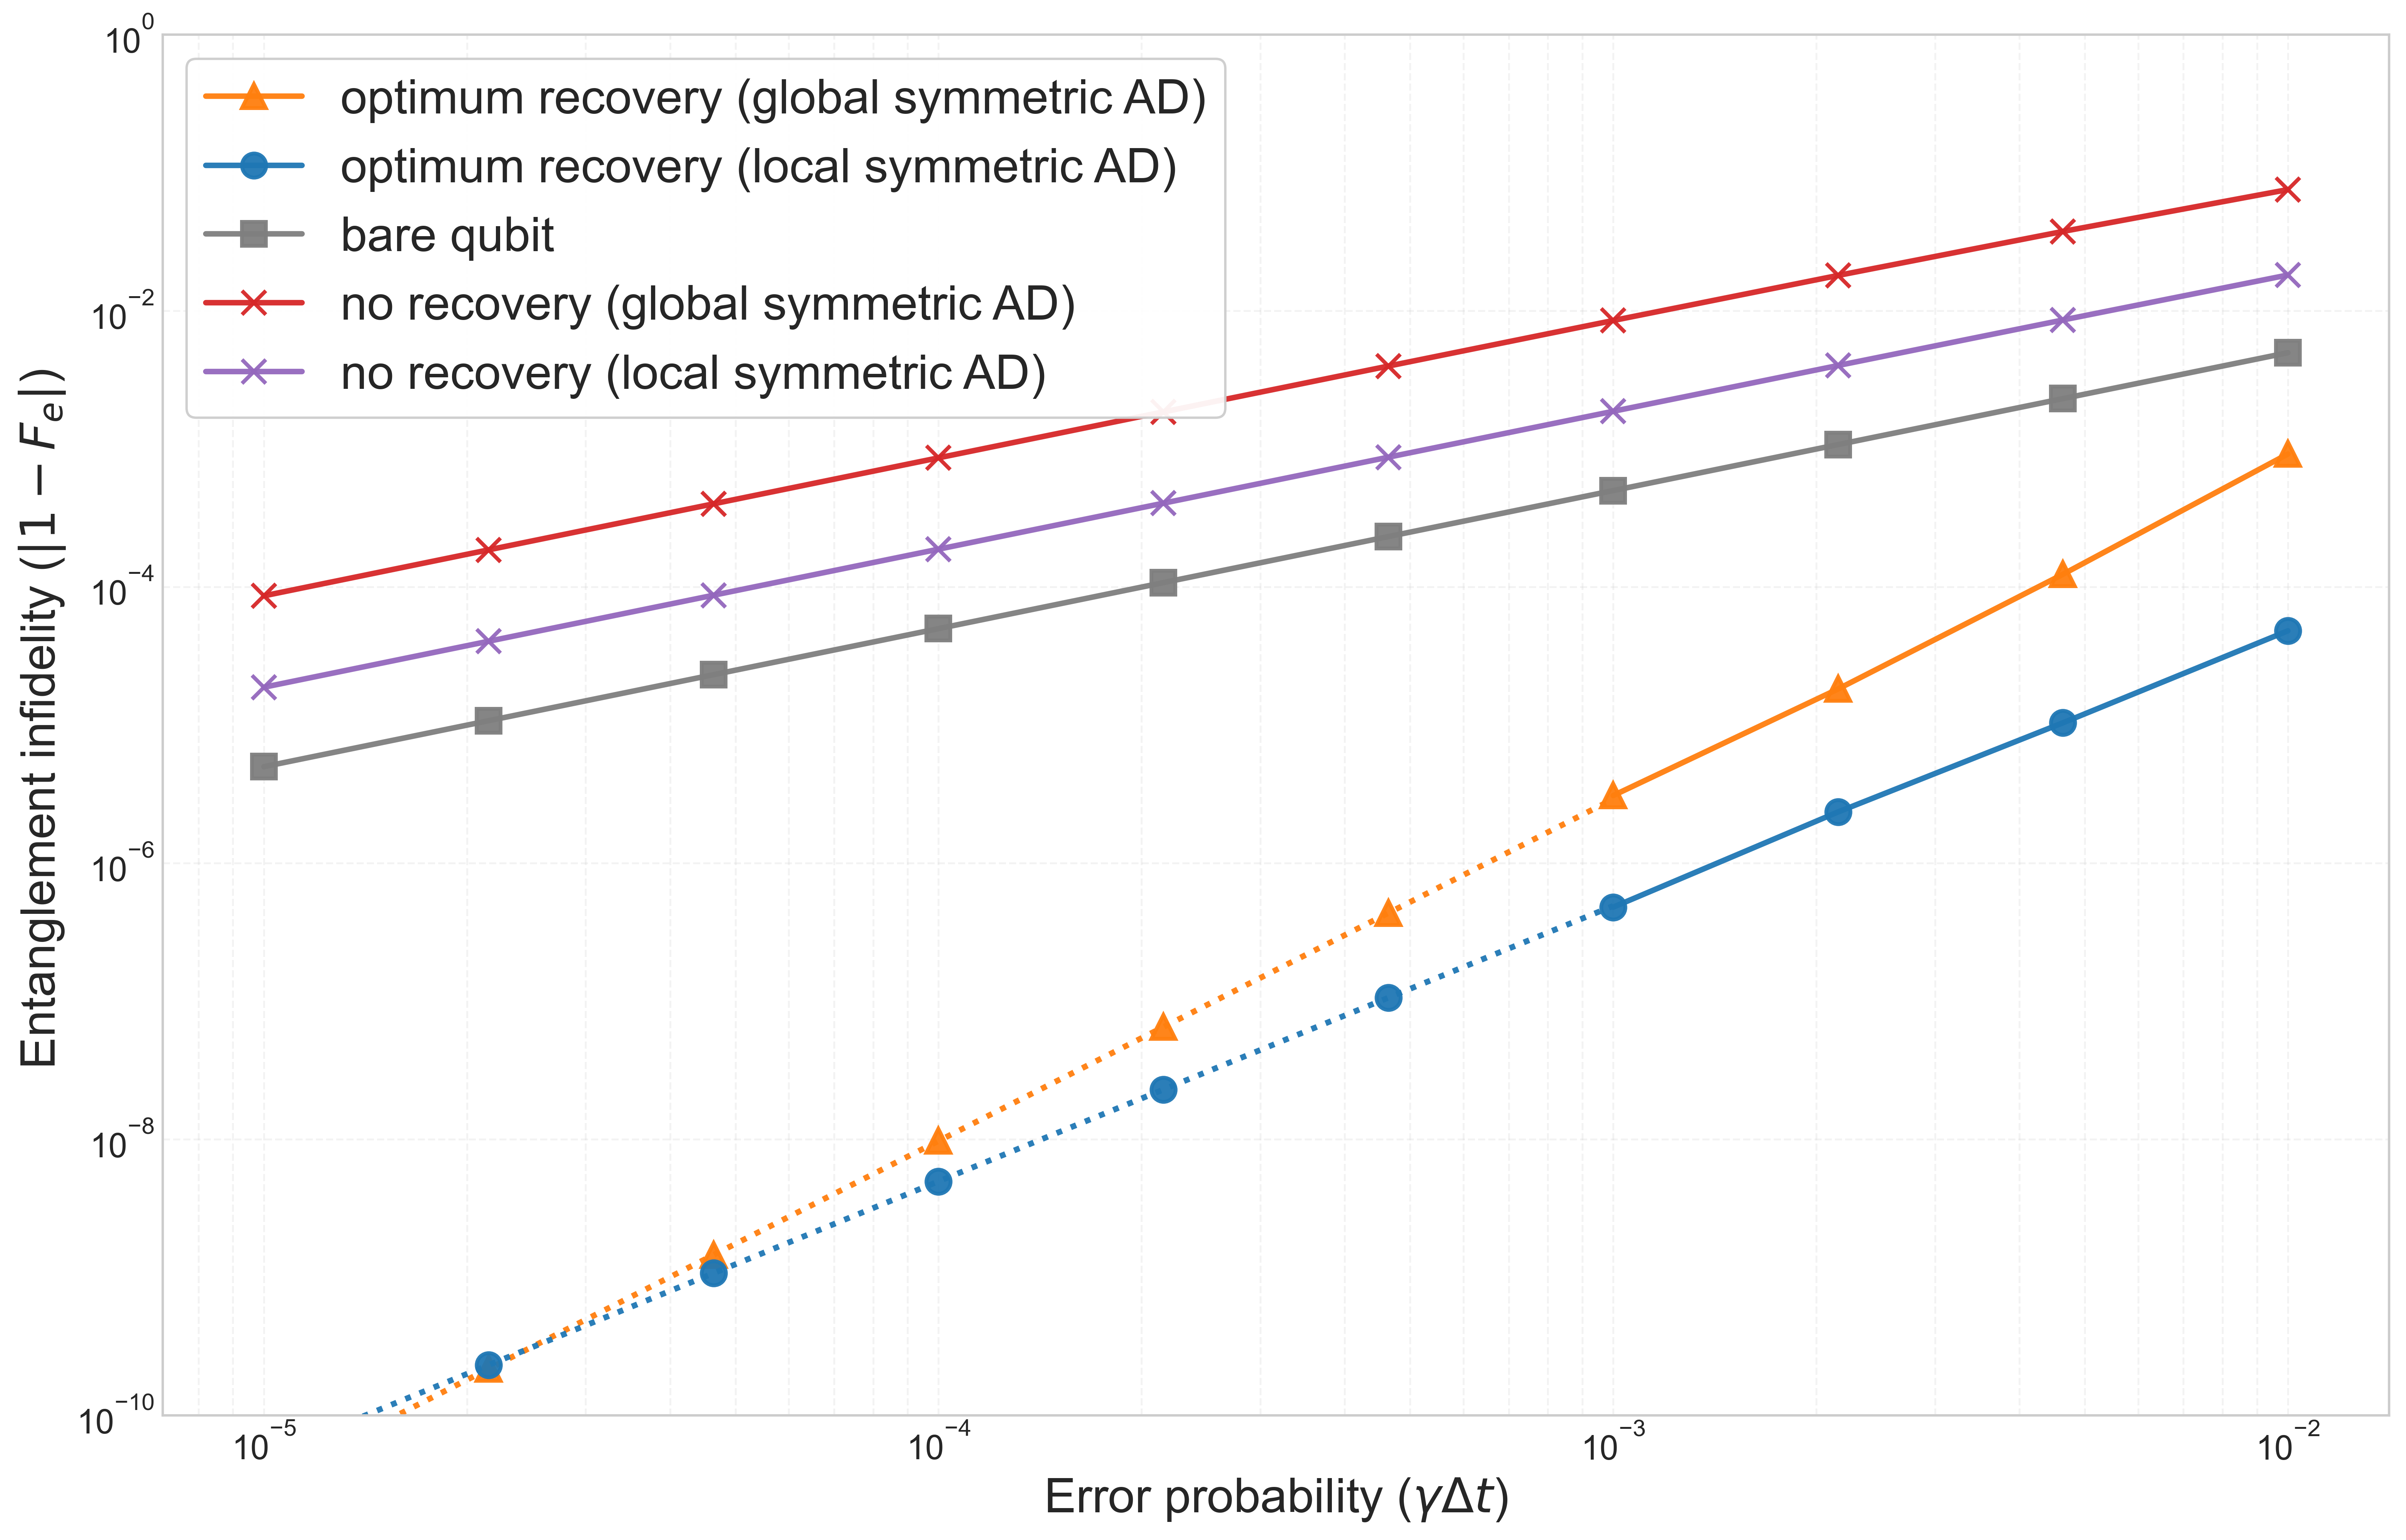

In [62]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

if "df_local" not in globals() or "df_global" not in globals():
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "README.md").exists():
            repo_root = candidate
            break
    if repo_root is None:
        repo_root = cwd

    data_dir = repo_root / "datas"
    df_local = pd.read_csv(data_dir / "local_amp_damp_results.csv")
    df_global = pd.read_csv(data_dir / "global_amp_damp_results.csv")

code = "bgm"
fit_threshold = 5e-4
fit_source_min = 1e-3
min_fit_points = 3
fig, ax = plt.subplots(figsize=(14.0, 9.0), dpi=450)
marker_size = 10
legend_fontsize = 20.0

series_specs = [
    (df_global, f"{code}_optimal", "optimum recovery (global symmetric AD)", "#ff7f0e", "^", "#ff7f0e", True),
    (df_local, f"{code}_optimal", "optimum recovery (local symmetric AD)", "#1f77b4", "o", "#1f77b4", True),
    (df_local, "bare_optimal", "bare qubit", "#7f7f7f", "s", "#7f7f7f", False),
    (df_global, f"{code}_no_recovery", "no recovery (global symmetric AD)", "#d62728", "x", "#d62728", False),
    (df_local, f"{code}_no_recovery", "no recovery (local symmetric AD)", "#9467bd", "x", "#9467bd", False),
]

def split_and_fit_low_gamma(p, y):
    valid = np.isfinite(p) & np.isfinite(y) & (p > 0) & (y > 0)
    p = p[valid]
    y = y[valid]

    order = np.argsort(p)
    p = p[order]
    y = y[order]

    low_mask = p < fit_threshold
    high_mask = p >= fit_threshold
    fit_mask = p >= fit_source_min

    coeff = None
    if np.count_nonzero(fit_mask) >= min_fit_points and np.any(low_mask):
        coeff = np.polyfit(np.log10(p[fit_mask]), np.log10(y[fit_mask]), 1)

    return p, y, low_mask, high_mask, coeff

for frame, column, label, color, marker, markerfacecolor, use_fit in series_specs:
    if column not in frame.columns:
        raise ValueError(f"Missing expected column '{column}'")
    data = frame[["gamma_dt", column]].dropna()
    p = data["gamma_dt"].to_numpy(dtype=float)
    y = data[column].to_numpy(dtype=float)
    p, y, low_mask, high_mask, coeff = split_and_fit_low_gamma(p, y)

    if not use_fit:
        ax.loglog(
            p,
            y,
            color=color,
            marker=marker,
            linestyle="-",
            lw=2.3,
            ms=marker_size,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            alpha=0.95,
            label=label,
        )
        continue

    if np.any(high_mask):
        ax.loglog(
            p[high_mask],
            y[high_mask],
            color=color,
            marker=marker,
            linestyle="-",
            lw=2.3,
            ms=marker_size,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            alpha=0.95,
            label=label,
        )

    if np.any(low_mask) and coeff is not None:
        fit_end = p[high_mask].min() if np.any(high_mask) else fit_threshold
        p_fit = np.logspace(np.log10(p[low_mask].min()), np.log10(fit_end), 80)
        y_fit = 10 ** np.polyval(coeff, np.log10(p_fit))
        ax.loglog(
            p_fit,
            y_fit,
            color=color,
            linestyle=":",
            lw=2.4,
            alpha=0.95,
        )
        y_fit_pts = 10 ** np.polyval(coeff, np.log10(p[low_mask]))
        ax.loglog(
            p[low_mask],
            y_fit_pts,
            color=color,
            marker=marker,
            linestyle="None",
            ms=marker_size,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markeredgewidth=1.6,
            alpha=0.95,
        )

#ax.set_title("3,3,1 BGM code: symmetric AD with and without optimum recovery", fontsize=18, pad=14)
ax.set_xlabel(r"Error probability ($\gamma \Delta t$)", fontsize=20)
ax.set_ylabel(r" Entanglement infidelity ($|1 - F_e|$)", fontsize=20)
ax.set_ylim(1e-10, 1.0)
ax.grid(True, which="both", ls="--", alpha=0.22)
ax.set_axisbelow(True)

ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.94,
    fontsize=legend_fontsize,
)

ax.tick_params(axis="both", which="major", labelsize=14)
fig.tight_layout()
plt.show()
